## Exploring META data and Generating Subfolders for FB_INF project

#### LOADING THE NECESSARY LIBRARIES TO EXPLORE THE METADATA GENERATED

In [1]:

%load_ext autoreload
%autoreload 2

from wormholes import *
from wormholes.perturb import *
from wormholes.tools.triplets_vis_tools import *
import matplotlib.pyplot as plt
import matplotlib.image as img
from argparse import Namespace
import os
import xarray as xr #this is to be able to read the .nc type of file
import shutil

In [2]:
# Set the HOME environment variable to your current working directory
os.environ["HOME"] = "/project/3018078.01/Gaziv/Wormholes_FB"

# Now the `os.path.expanduser("~")` will resolve to this directory
print(os.path.expanduser("~")) 

/project/3018078.01/Gaziv/Wormholes_FB


This next part of the script is loading the meta data file and does some exploration of the variables that have been defined there. 

In [3]:
#this is the directory where they will find the images (change as you deem necessary)
##TODO: check that it works with a different directory

# exp_root = f"{PROJECT_ROOT}/results/cache/gen_v4"
exp_root = f"{PROJECT_ROOT}/results/cache/placeholder/gen_v4"

# Load the metadata file
metadata = xr.open_dataset(f"{exp_root}/meta.nc")

# Print metadata structure
print(metadata)

# List variables in the dataset
#print(metadata.variables)

<xarray.Dataset>
Dimensions:                                   (image_id: 20520, class_index: 9,
                                               model_subject_name: 8)
Coordinates:
  * image_id                                  (image_id) object '03d70deecdff...
  * class_index                               (class_index) int64 0 1 2 ... 7 8
  * model_subject_name                        (model_subject_name) object 're...
Data variables: (12/15)
    model_name                                (image_id) object ...
    budget                                    (image_id) float64 ...
    n_iter                                    (image_id) int64 ...
    step_size                                 (image_id) float64 ...
    interp_alpha                              (image_id) float64 ...
    target_class_name                         (image_id) object ...
    ...                                        ...
    budget_usage                              (image_id) float64 ...
    target_image_path   

I am now transforming the .nc file into a Pandas dataframe, as this is the type of structure I am familiar with and allows me to do the selection of relevant information I need for my experiment

In [4]:
#Depending on the size of the meta.nc file. The kernel might get overwhemled when trying to trasnform it to a pandas dataframe. 
#Therefore, the next couple of code lines are to only pass the information that is relevant (reducing the size of df)
selected_vars = ["model_name", "budget", "image_id",'class_index', 'pred_logit',
                 'model_subject_name', 'orig_class_name', 'orig_name']
df = metadata[selected_vars].to_dataframe().reset_index()

# Convert the dataset to a Pandas DataFrame (this is because I am most comfortable using Pandas df)
# df = metadata.to_dataframe().reset_index()

# Inspect the metadata structure
print(df.head())

# Inspect the columns in the Pandas Dataframe
print(df.columns)

#information about the data in the columns
df.info(verbose=False)

                               image_id  class_index  \
0  03d70deecdffd5177e2aa0e137f69b25.png            0   
1  03d70deecdffd5177e2aa0e137f69b25.png            0   
2  03d70deecdffd5177e2aa0e137f69b25.png            0   
3  03d70deecdffd5177e2aa0e137f69b25.png            0   
4  03d70deecdffd5177e2aa0e137f69b25.png            0   

                      model_subject_name                          model_name  \
0     resnet50_robust_mapped_RIN_l2_10_0  resnet50_robust_mapped_RIN_l2_10_0   
1  resnet50_robust_mapped_RIN_l2_10_0_v2  resnet50_robust_mapped_RIN_l2_10_0   
2      resnet50_robust_mapped_RIN_l2_1_0  resnet50_robust_mapped_RIN_l2_10_0   
3   resnet50_robust_mapped_RIN_l2_1_0_v2  resnet50_robust_mapped_RIN_l2_10_0   
4      resnet50_robust_mapped_RIN_l2_3_0  resnet50_robust_mapped_RIN_l2_10_0   

   budget  pred_logit orig_class_name  \
0     0.0    0.707338            frog   
1     0.0    1.118970            frog   
2     0.0         NaN            frog   
3     0.0    3.223

I am now filtering the dataframe so it only includes the parameters that are relevant for my experiment. 
With the filtered data frame I can then create folders with the relevant images for the experiment (with the correct names)

NOTE: model_name is the variable used to define which model is being used to generate the adversarial images. model_subject_name is all the other models that will be tested on the adversarial images generated by model_name and compare their performances. 

In [5]:
#The following lines of code are ways of probing the df. Not necessary, but useful

# print(df['model_name'].unique()) # displays all the networks available to extract images from
# print(df['model_subject_name'].unique()) #the v2 versions of the networks are just initialized using different seeds
# print(df['budget'].unique()) #all the budget options I can select images from


# Apply filtering

filtered_df = df[(df['model_name'] == 'resnet50_robust_mapped_RIN_l2_3_0') & (df['budget'] == 10) & (df['model_subject_name'] == 'resnet50_robust_mapped_RIN_l2_3_0')] 
print(filtered_df.head())
# print(filtered_df.columns)
# print(filtered_df['model_name'])
# print(len(filtered_df['image_id'].unique()))
filtered_df.shape
print(filtered_df['class_index'].unique())

#Code to visualize any image we want on the dataset
# im = img.imread(f"{exp_root}/images/30a0f974d91cf438f69c726c9434678b.png")
# plt.imshow(im)


                                    image_id  class_index  \
894244  71f092456eaa73acc02191f704f8cb87.png            0   
894252  71f092456eaa73acc02191f704f8cb87.png            1   
894260  71f092456eaa73acc02191f704f8cb87.png            2   
894268  71f092456eaa73acc02191f704f8cb87.png            3   
894276  71f092456eaa73acc02191f704f8cb87.png            4   

                       model_subject_name                         model_name  \
894244  resnet50_robust_mapped_RIN_l2_3_0  resnet50_robust_mapped_RIN_l2_3_0   
894252  resnet50_robust_mapped_RIN_l2_3_0  resnet50_robust_mapped_RIN_l2_3_0   
894260  resnet50_robust_mapped_RIN_l2_3_0  resnet50_robust_mapped_RIN_l2_3_0   
894268  resnet50_robust_mapped_RIN_l2_3_0  resnet50_robust_mapped_RIN_l2_3_0   
894276  resnet50_robust_mapped_RIN_l2_3_0  resnet50_robust_mapped_RIN_l2_3_0   

        budget  pred_logit orig_class_name  \
894244    10.0    1.532246            frog   
894252    10.0    1.785079            frog   
894260    10.0

In the code above, the filtered_df now consists of only rows with 9 classes x 30 images x which of the 9 classes the current image is classified as (this information might be relevant then to probe whether certain classes are more likely to be transformed into other classes). I should ask Lea about this. 

I will create a histogram per class to see the distribution of the selected classes and assess whether there is any detected systematicity in the PGD


=== max_class_per_image for bird ===
                                    image_id  class_index
900684  0750d3c66f0f3141cc8ccc1357a3810d.png            4
899860  1fd73828395059953f1dc9f70524adfc.png            0
899148  243cbb1642029f15044d02af4954d927.png            1
900572  246811185e351e8b3fb0a4be681fcefb.png            8
899932  28d1e348723709b8fb3c134ddfa8e5d4.png            0

=== counts for bird (before mapping) ===
0    9
1    1
2    2
3    1
4    1
5    2
6    1
7    5
8    8
Name: class_index, dtype: int64


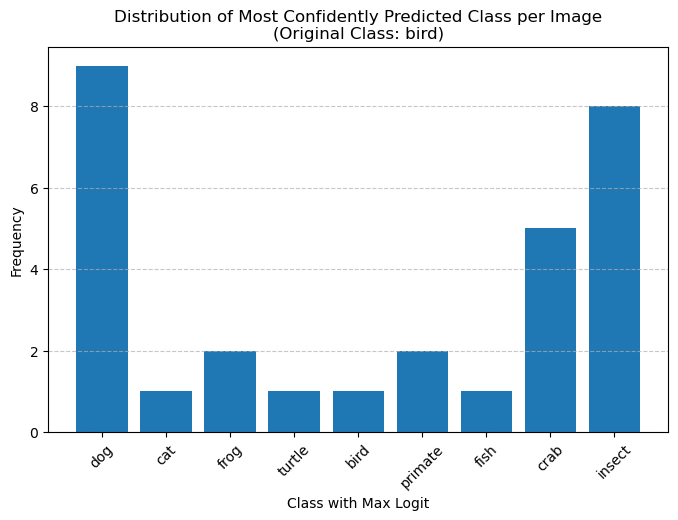


=== max_class_per_image for cat ===
                                    image_id  class_index
905404  00bf375bbceafc4a0a280704aa917260.png            0
905908  1374533c94295901284f1935a094d3f6.png            0
905692  2209bc3ebcba88efc771ef3354b5231a.png            0
906988  27832056bf289c691dbc900d1b1cc8f9.png            0
905980  2bd42f19168963835db2f23705b03e40.png            0

=== counts for cat (before mapping) ===
0    22
1     1
2     2
4     2
5     2
7     1
Name: class_index, dtype: int64


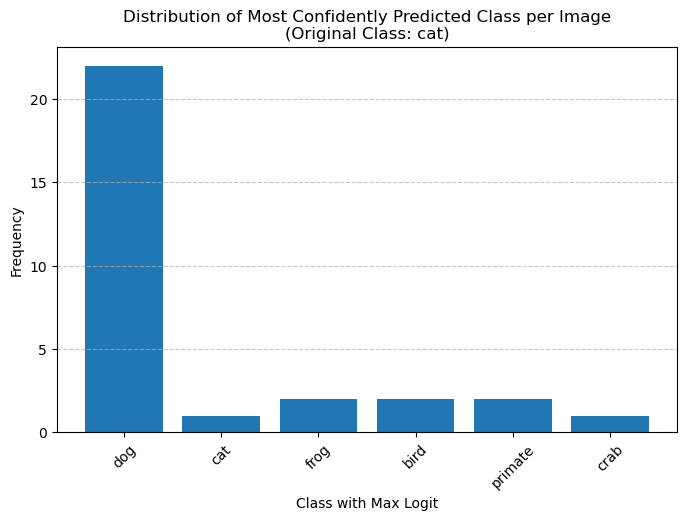


=== max_class_per_image for crab ===
                                    image_id  class_index
902300  256b5658cf0ca0de41bcef9198087ae8.png            8
901988  381388a84487652e9d5101a12280e968.png            5
901652  3a1189d1d9df46b60b22c3f5a312cb64.png            8
901908  454d55b9bd8ecbcab7f357d16ddd78dc.png            4
901036  4d492f9c5b909e6259237eebd2c57aea.png            3

=== counts for crab (before mapping) ===
2     5
3     3
4     3
5     3
6     5
8    11
Name: class_index, dtype: int64


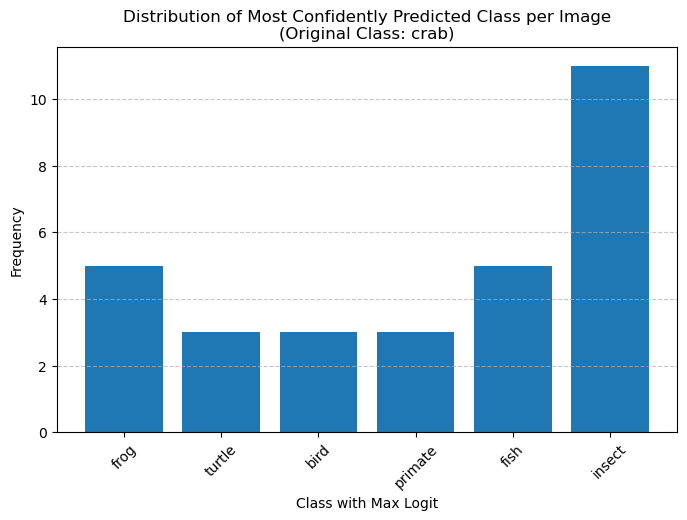


=== max_class_per_image for dog ===
                                    image_id  class_index
903324  120b0ba56499cfe87bac48149e5d1317.png            1
904548  2b55d47510b2606b657a509723ca6f70.png            1
903828  3322eddc5c3786f5e880d918b2d28488.png            1
903108  398fcb5b182b74ce2a2aedb7ddd29383.png            1
904924  46a0ec3371f3f53ffb6e32fcafd973d2.png            3

=== counts for dog (before mapping) ===
1    17
2     3
3     2
4     3
5     4
8     1
Name: class_index, dtype: int64


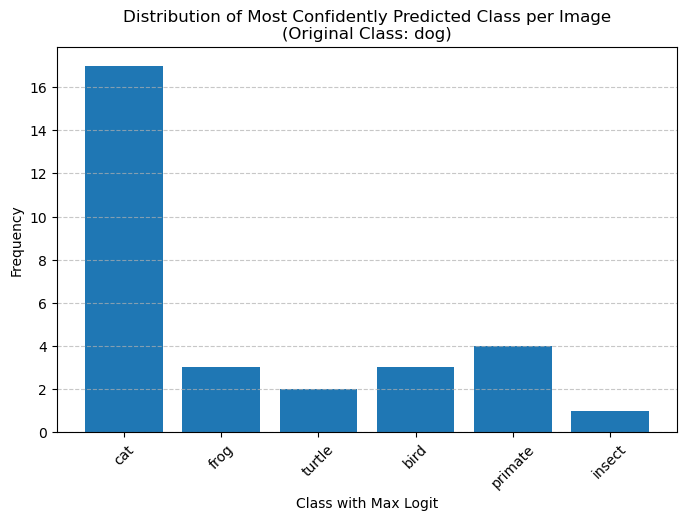


=== max_class_per_image for fish ===
                                    image_id  class_index
912196  06fb41453525312a2f3d52717396b43c.png            3
912796  0e556882f7ba5e653b194aee9b53c67f.png            6
912140  10d91dbc68ad1327098f3bfc54bcb4b8.png            5
913540  1258f4bfb326ffaf5747568eaa6ca4b0.png            0
911948  209d7e6bfd24b6567b63d4ff318dcaf3.png            8

=== counts for fish (before mapping) ===
0    3
2    2
3    3
4    4
5    7
6    4
7    3
8    4
Name: class_index, dtype: int64


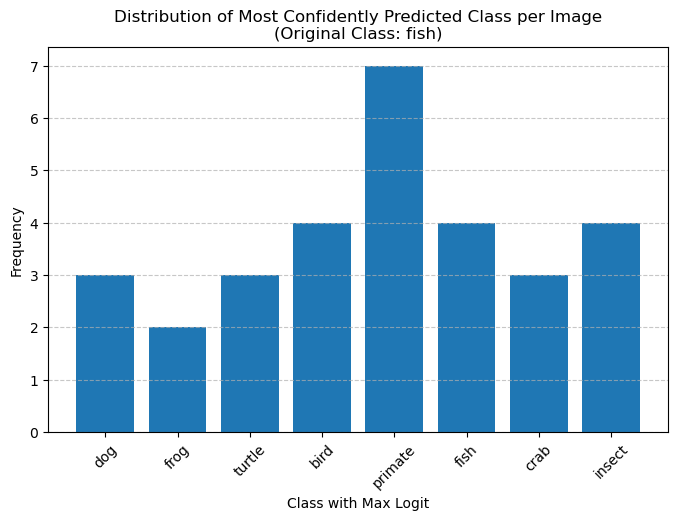


=== max_class_per_image for frog ===
                                    image_id  class_index
895388  026f0467edcbc3d0ac0726031a3f7808.png            8
895244  21069e9de4e3ec426c8fe1b16248dd15.png            8
894812  2226069ea7ddbb00a5e541e94fcf52f5.png            8
895748  37f419b2c5933d48c4287500cc603a80.png            8
895012  47d883e8342090c7cc8313b04514bb08.png            6

=== counts for frog (before mapping) ===
2     2
3     6
4     2
6     1
7     3
8    16
Name: class_index, dtype: int64


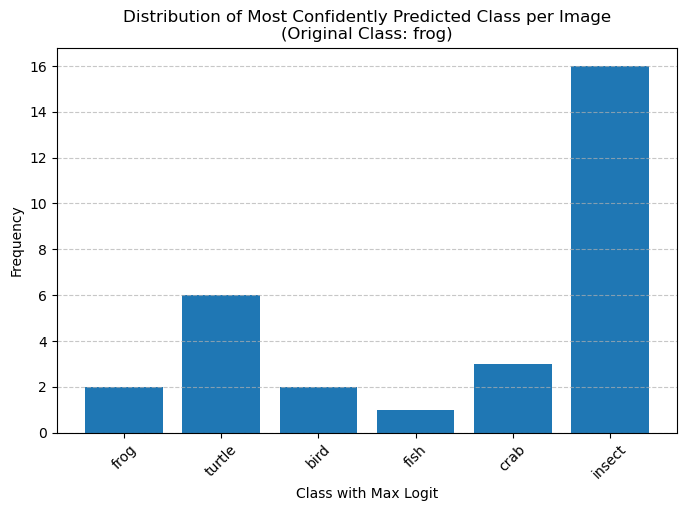


=== max_class_per_image for insect ===
                                    image_id  class_index
908788  038a4851f88a6c645a7b2058ca0409d5.png            0
909356  06b5bcdc00fb00d563f22f9768519566.png            8
907308  12c7fbb1ab03036fa526292a4b5b9423.png            4
908708  140996b624185d7f34a9bc26c0b4bb0e.png            8
908988  14ce67b2d75d40c0d68041900ab2ff81.png            7

=== counts for insect (before mapping) ===
0     2
2     5
3     1
4    11
5     1
7     6
8     4
Name: class_index, dtype: int64


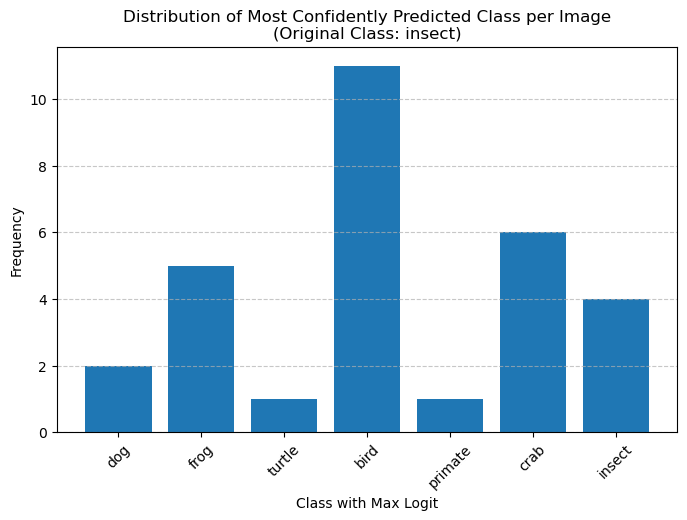


=== max_class_per_image for primate ===
                                    image_id  class_index
910228  07158f49ba8918757bc6bb77e17fd069.png            0
910948  15a137d0e7bb162b226a61dc9bf75163.png            0
909940  1c487f4c935d2833a01c05221f097d38.png            0
910660  1c770299b8fc60662545e4ddf3c4fa68.png            0
911092  1d7bca524dcff06ba32f3581510e6c39.png            0

=== counts for primate (before mapping) ===
0    24
4     5
7     1
Name: class_index, dtype: int64


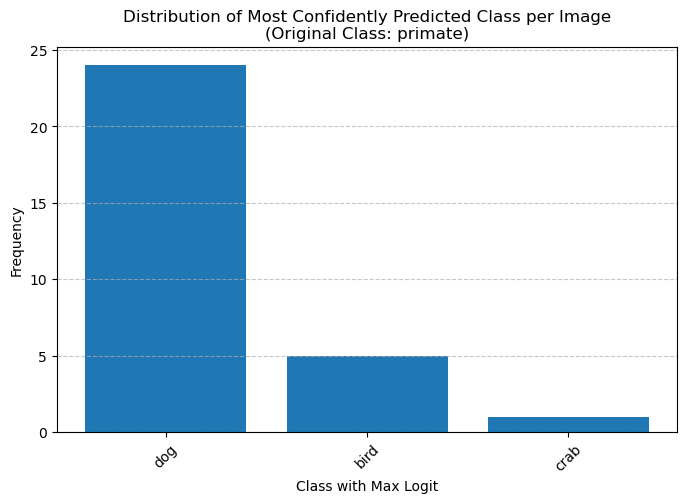


=== max_class_per_image for turtle ===
                                    image_id  class_index
897116  2456ae36b9000a48d1b2c980dd050cb6.png            8
897972  2fdde896164412f08dbe4c30c3d604a0.png            7
898340  3c378abced57fa36e514a39d1d7da29b.png            8
898468  3cdde22bb4498e364f8aa0a0f409e143.png            6
898252  3d99ed2409e7165f41ddceb78123e3e3.png            6

=== counts for turtle (before mapping) ===
0     2
4     3
6     9
7     6
8    10
Name: class_index, dtype: int64


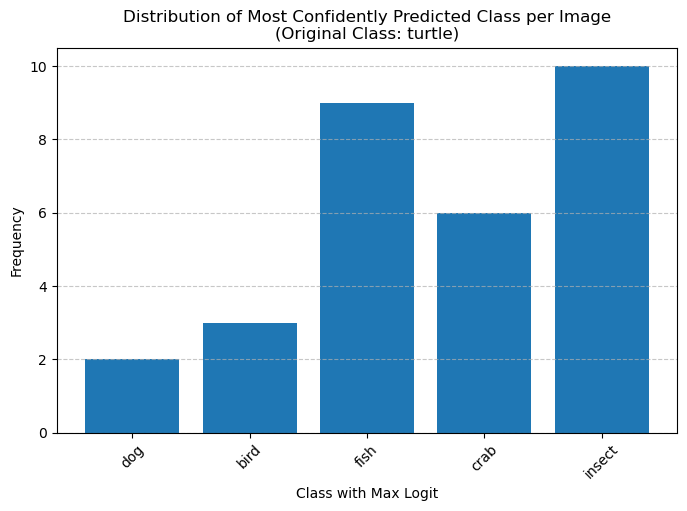

In [6]:

# Mapping of class_index to labels
class_labels = {
    0: "dog", 1: "cat", 2: "frog", 3: "turtle", 4: "bird",
    5: "primate", 6: "fish", 7: "crab", 8: "insect"
}

# class_labels = { 0: 'dog', 1: 'cat', 
#                    2: 'frog', 3: 'turtle', 4: 'bird', 
#                    5: 'primate', 6: 'fish', 7: 'crab', 
#                    8: 'insect', 9: 'bear', 10: 'snake', 11: 'rabbit'}


def plot_max_class_histogram_per_orig_class(df):
    """
    Plots histograms of the most frequently predicted class_index per image, separately for each orig_class_name.

    Parameters:
        df (pd.DataFrame): A DataFrame containing 'orig_class_name', 'image_id', 'class_index', and 'pred_logit'.

    Returns:
        None
    """
    # Loop over each original class
    for orig_class, sub_df in df.groupby("orig_class_name"):
        # Find the class_index with the highest pred_logit for each image
        max_class_per_image = sub_df.loc[sub_df.groupby("image_id")["pred_logit"].idxmax(), ["image_id", "class_index"]]

        # Print the DataFrame containing only the highest logit per image
        print(f"\n=== max_class_per_image for {orig_class} ===")
        print(max_class_per_image.head())  # Print first few rows to inspect

        # Count occurrences of each class_index being the max
        class_counts = max_class_per_image["class_index"].value_counts().sort_index()

        # Print the counts before mapping to class labels
        print(f"\n=== counts for {orig_class} (before mapping) ===")
        print(class_counts)

        # Map class_index to class labels
        class_labels_mapped = [class_labels[idx] for idx in class_counts.index]

        # Plot histogram
        plt.figure(figsize=(8, 5))
        plt.bar(class_labels_mapped, class_counts.values)
        plt.xlabel("Class with Max Logit")
        plt.ylabel("Frequency")
        plt.title(f"Distribution of Most Confidently Predicted Class per Image\n(Original Class: {orig_class})")
        plt.xticks(rotation=45)  # Rotate labels for readability
        plt.grid(axis="y", linestyle="--", alpha=0.7)
        plt.show()


plot_max_class_histogram_per_orig_class(filtered_df)


### Understanding logit distributions 
The plots above show me over all the images, which class the network selected as the most likely. 
I now want to plot across all images, the mean logit for each class (this will give me insights into how the cross entropy loss is being maximized by the network)


=== Mean logits for bird (before mapping) ===
class_index
0    6.015062
1    3.278309
2    4.457139
3    4.903512
4    5.144304
5    3.337084
6    2.922667
7    4.721524
8    7.106178
Name: pred_logit, dtype: float64


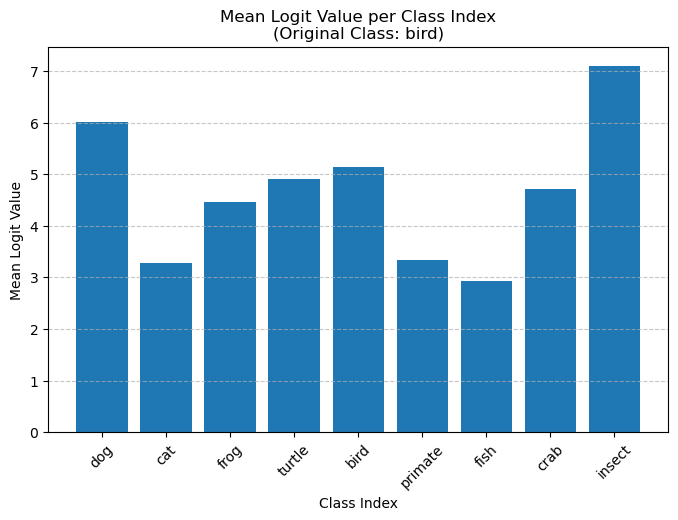


=== Mean logits for cat (before mapping) ===
class_index
0    11.494574
1     5.425157
2     1.743482
3     2.456620
4     3.817689
5     4.730815
6     2.262743
7     1.372258
8     1.821011
Name: pred_logit, dtype: float64


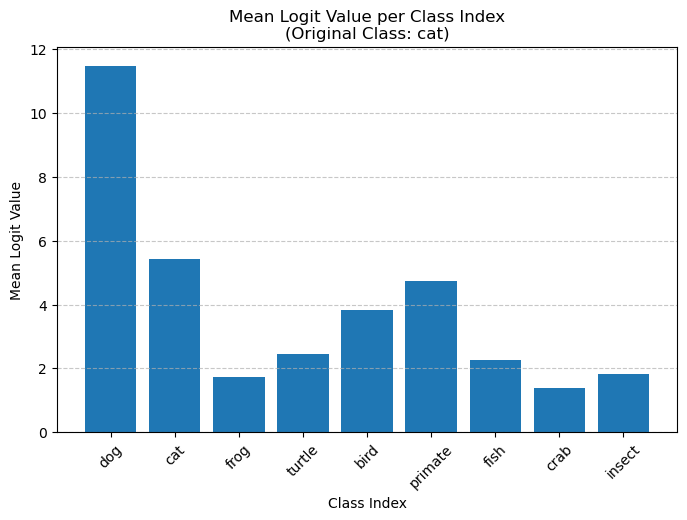


=== Mean logits for crab (before mapping) ===
class_index
0    3.337735
1    2.297235
2    6.985293
3    7.016607
4    5.800379
5    3.617357
6    6.350058
7    6.195874
8    8.703190
Name: pred_logit, dtype: float64


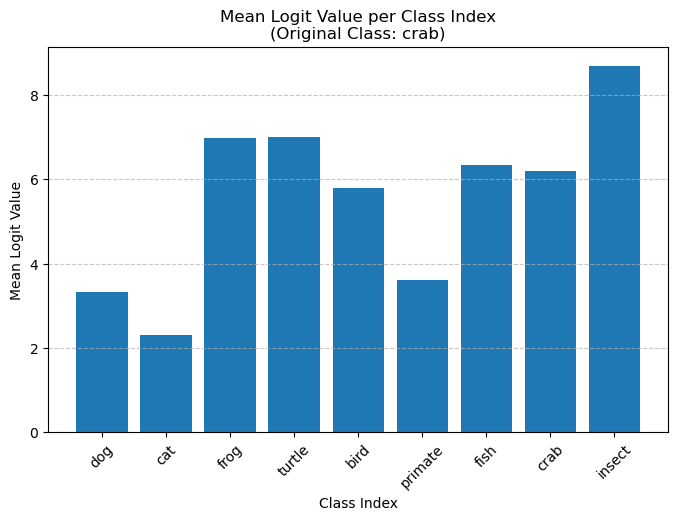


=== Mean logits for dog (before mapping) ===
class_index
0    6.507411
1    9.314357
2    2.014565
3    2.575369
4    3.923707
5    4.937641
6    2.213005
7    0.932299
8    2.580813
Name: pred_logit, dtype: float64


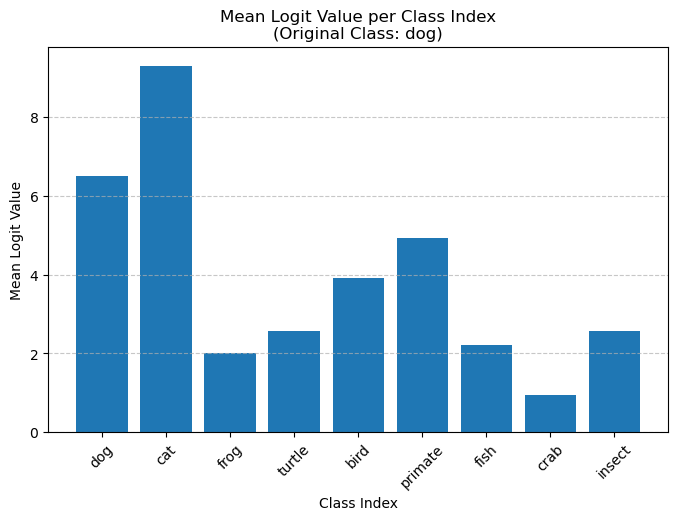


=== Mean logits for fish (before mapping) ===
class_index
0    4.819082
1    2.126841
2    3.516930
3    5.062805
4    4.967329
5    5.376827
6    7.968853
7    4.480580
8    4.604921
Name: pred_logit, dtype: float64


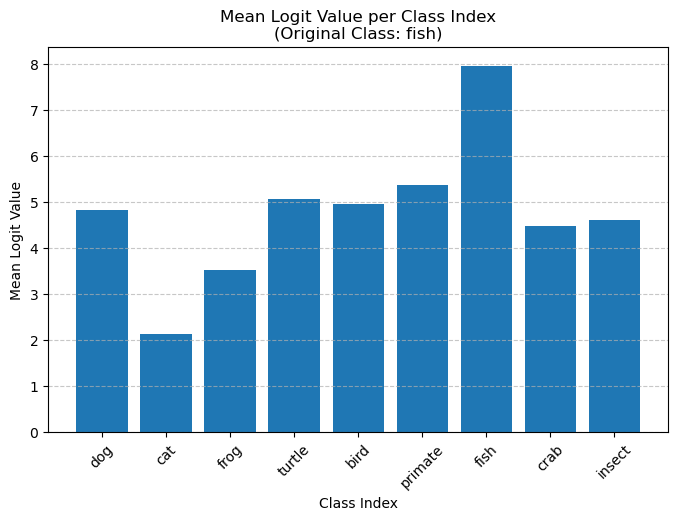


=== Mean logits for frog (before mapping) ===
class_index
0     2.256043
1     1.912122
2     7.063250
3     7.179124
4     5.523714
5     2.836456
6     5.014386
7     6.193961
8    12.182917
Name: pred_logit, dtype: float64


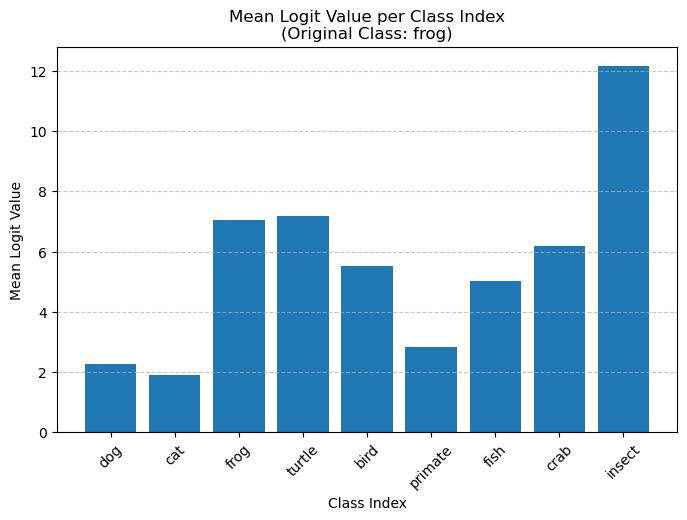


=== Mean logits for insect (before mapping) ===
class_index
0    3.445531
1    2.026658
2    5.964368
3    5.034209
4    8.512920
5    3.209704
6    3.429344
7    6.313876
8    8.422294
Name: pred_logit, dtype: float64


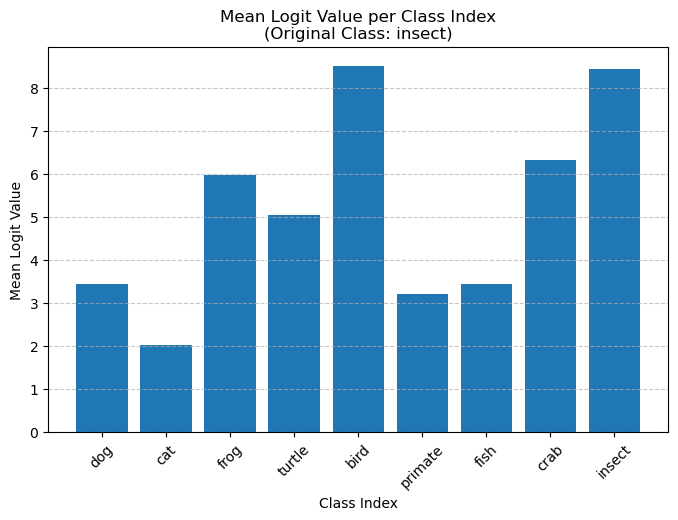


=== Mean logits for primate (before mapping) ===
class_index
0    12.481575
1     4.064498
2     0.300293
3     1.816075
4     5.436307
5     6.569784
6     1.632459
7     0.830319
8     1.609055
Name: pred_logit, dtype: float64


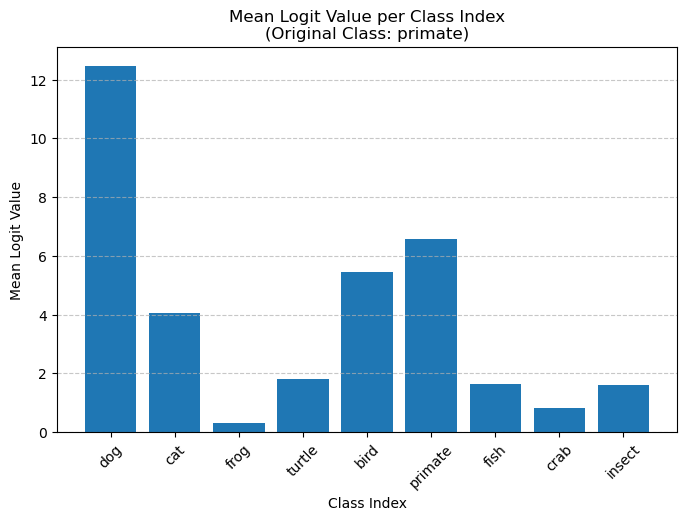


=== Mean logits for turtle (before mapping) ===
class_index
0    3.153197
1    0.951527
2    4.051328
3    5.656392
4    4.563268
5    2.003056
6    6.793261
7    6.577984
8    8.641119
Name: pred_logit, dtype: float64


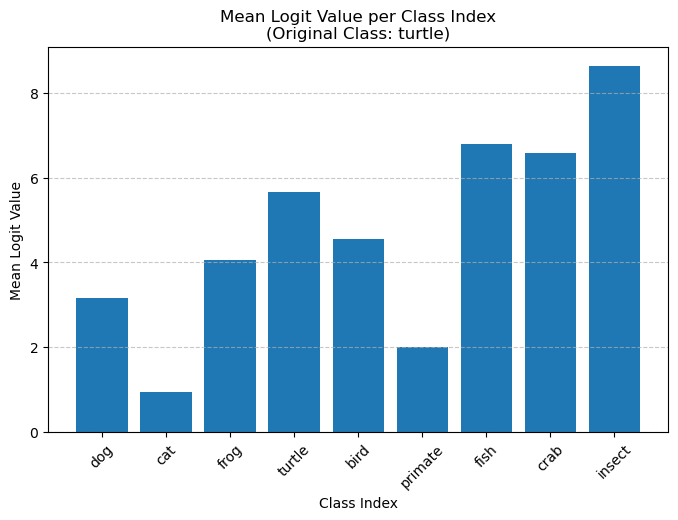

In [7]:

def plot_mean_logit_histogram_per_orig_class(df):
    """
    Plots histograms of the mean logit value per class_index for all images belonging to a specific orig_class_name.

    Parameters:
        df (pd.DataFrame): A DataFrame containing 'orig_class_name', 'image_id', 'class_index', and 'pred_logit'.

    Returns:
        None
    """
    for orig_class, sub_df in df.groupby("orig_class_name"):
        # Compute mean logit per class_index
        mean_logit_per_class = sub_df.groupby("class_index")["pred_logit"].mean()
        
        # Print the mean logits before mapping to class labels
        print(f"\n=== Mean logits for {orig_class} (before mapping) ===")
        print(mean_logit_per_class)
        
        # Map class_index to class labels
        class_labels_mapped = [class_labels[idx] for idx in mean_logit_per_class.index]
        
        # Plot histogram
        plt.figure(figsize=(8, 5))
        plt.bar(class_labels_mapped, mean_logit_per_class.values)
        plt.xlabel("Class Index")
        plt.ylabel("Mean Logit Value")
        plt.title(f"Mean Logit Value per Class Index\n(Original Class: {orig_class})")
        plt.xticks(rotation=45)
        plt.grid(axis="y", linestyle="--", alpha=0.7)
        plt.show()

# Call the function
plot_mean_logit_histogram_per_orig_class(filtered_df)

Now, I want to generate code that creates a new folder with all my perturbed images. 
I will devise a specific form of naming them that will make it easier for me to use in the actual experiment. 

naming convention = original/perturbed_imgclass_budget_imgnumber

I will create first an overall folder, then a folder with subfolders per each class (easier for manipulation of images)

I will then create a final folder with only the selected images

In [8]:
#Creating a new folder with images per class, renamed and easy for me to visualize and filter out later.

output_folder_root = "/project/3018078.01/FB_INF/stimulus_set"

def folder_per_class (df, pert_or_orig):
    """
    Generates folders in the output_folder_root for each of the Restricted ImageNet classes and provides a specific naming convention. 
    It has both the original image (taken from Imagenet validation set) as well as the perturbed image (budget defined above in the notebook)

    Parameters:
        df (pd.DataFrame): A DataFrame of the MetaData containing 'orig_class_name', 'image_id', 'class_index', and 'pred_logit'.
        If the notebook is being followed sequentially. This df should be the filtered df, using the filters desired.
        pert_or_orig (string): A string indicating which images you want the function to generate. Because the dataframe for the 
        origin images that have been cropped is different than the df for the perturbed. The function is divided in two. 

    Returns:
        None

    Output:
        In the output_folder_root you should see your new folders with the images named according to the description:
        1. original_orig_class_name_budget_number -- for the original ilsrvc val dataset
        2. perturbed_orig_class_name_budget_number -- for the perturbed genv4 images

        number is just a numebr from image 0 to the maximum image generated
    """
    # Loop over each original class
    for orig_class, sub_df in df.groupby("orig_class_name"):
        #create a folder in the directory where I will store the images
        folder_dir_path = os.path.join(output_folder_root, str(orig_class))
        
        # Create the folder if it doesn't exist
        os.makedirs(folder_dir_path, exist_ok=True)
        sub_df = sub_df[sub_df['class_index'] == 0]

        for i, row in enumerate(sub_df.itertuples(index=False)):
              if pert_or_orig == 'perturbed':
                #create a file name (according to my naming convention) for perturbed images and cpy them to the output_folder_root
                file_name = f"perturbed_{row.orig_class_name}_{row.budget}_{i+1}.png"
                destination_path = os.path.join(folder_dir_path, file_name)
                source_path = os.path.join(exp_root, f'images/{row.image_id}')
                shutil.copy(source_path, destination_path)
              elif pert_or_orig == 'original':
                file_name_og = f"original_{row.orig_class_name}_{row.budget}_{i+1}.JPEG"
                destination_path_og = os.path.join(folder_dir_path, file_name_og)
                source_path_og = os.path.join(os.path.expanduser('~'), f'data/{row.orig_name}')
                shutil.copy(source_path_og, destination_path_og)
              else:
                print("Insert a valid option: 'perturbed' or 'original' ")

folder_per_class(filtered_df, 'perturbed')

